# Dataset

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd



california_housing = fetch_california_housing(as_frame=True)

X = california_housing.data
y = california_housing.target

In [3]:
#     - MedInc        median income in block group
#     - HouseAge      median house age in block group
#     - AveRooms      average number of rooms per household
#     - AveBedrms     average number of bedrooms per household
#     - Population    block group population
#     - AveOccup      average number of household members
#     - Latitude      block group latitude
#     - Longitude     block group longitude

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [4]:
# Problema de regresión
# valor mediano de la casa para cada distrito

y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# Model

In [8]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=99)
model.fit(X_train, y_train)
y_hat = model.predict(X_test)
root_mean_squared_error(y_true=y_test, y_pred=y_hat)

np.float64(0.459134599109587)

In [11]:
# model.feature_importances_

# SHAP

In [14]:
# shap.TreeExplainer: Modelos basados en árboles (XGBoost, LightGBM, CatBoost, Random Forest, Decision Trees de scikit-learn).
# shap.KernelExplainer: Cualquier tipo de modelo (SVM, Regresión Lineal/Logística genérica, K-NN, Redes Neuronales si no se usa DeepExplainer, modelos personalizados, etc.).
# shap.DeepExplainer: Redes neuronales profundas (MLP, CNN, RNN) en frameworks como TensorFlow/Keras y PyTorch.
# shap.LinearExplainer: Modelos lineales (Regresión Lineal, Regresión Logística).
# shap.GradientExplainer: Redes neuronales y otros modelos que pueden calcular gradientes.
# shap.Explainer (API Unificada): Cualquier tipo de modelo (selecciona automáticamente el mejor explainer subyacente).

In [15]:
import shap

explainer = shap.TreeExplainer(model)

C:\Users\efclprd\anaconda3\envs\ml_python\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
shap_values = explainer.shap_values(X_test)
shap_values

array([[-2.2211698e-01,  1.1987402e-02, -1.6743867e-01, ...,
        -3.3095670e-01,  3.5064042e-01, -2.1346076e-01],
       [-2.8730071e-01, -9.3993935e-04,  4.9511477e-02, ...,
        -3.6658785e-01,  2.2318678e-01, -6.5580326e-01],
       [-4.7854280e-01,  2.1233233e-02, -1.6166845e-01, ...,
         5.5309299e-02, -1.2319096e+00,  5.5019987e-01],
       ...,
       [-2.7687791e-01, -6.9251605e-03, -7.0818871e-02, ...,
        -8.2742712e-03, -1.4288220e+00,  7.6741505e-01],
       [ 1.8377347e+00, -7.3476098e-02,  3.0537602e-01, ...,
        -4.1501325e-02,  6.6763884e-01,  1.5466175e-02],
       [-1.0414692e-02, -4.0823016e-02,  2.2271853e-02, ...,
        -2.5346395e-01, -7.8289407e-01,  8.1830680e-02]], dtype=float32)

In [17]:
shap_values.shape

(4128, 8)

In [19]:
# para cada record, tenemos 8 shap values para 8 features

X_test.shape

(4128, 8)


In [33]:
# Cada valor en esta matriz representa la contribución de una característica a la diferencia entre la predicción media esperada
# (expected value) y la predicción real para una instancia específica.

In [25]:
expected_value = explainer.expected_value
expected_value

np.float32(2.0740123)

In [26]:
y_hat.mean()  # no es igual, pero tiende a aproximarse

np.float32(2.0527372)

### Summary plot

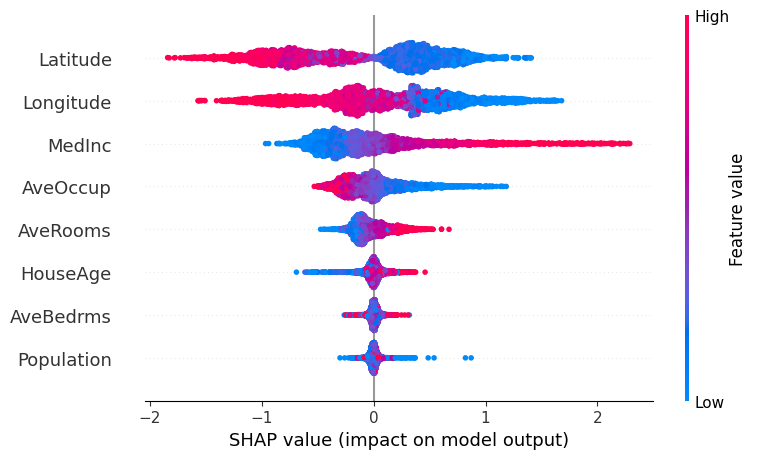

In [20]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test)
plt.show()

# valores positivos de SHAP indican que impactan a valores altos de y
# valores negativos de SHAP indican que imapctan a valores bajos de y

# Por ejemplo MedInc
# Un alto ingreso mediano en un distrito es un factor muy potente y consistente que hace que 
# el precio predicho de la vivienda en ese distrito sea significativamente más alto 
# que el precio base (el expected_value) del modelo.

## Partial dependence plot

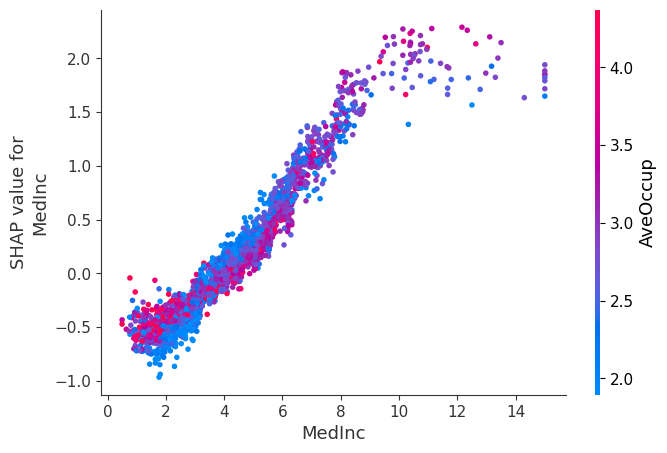

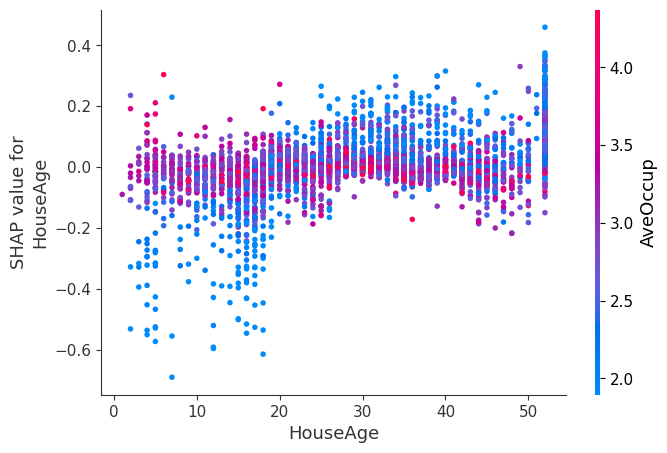

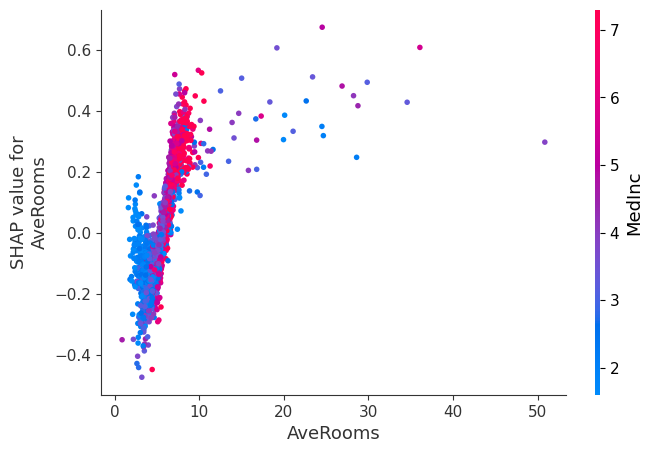

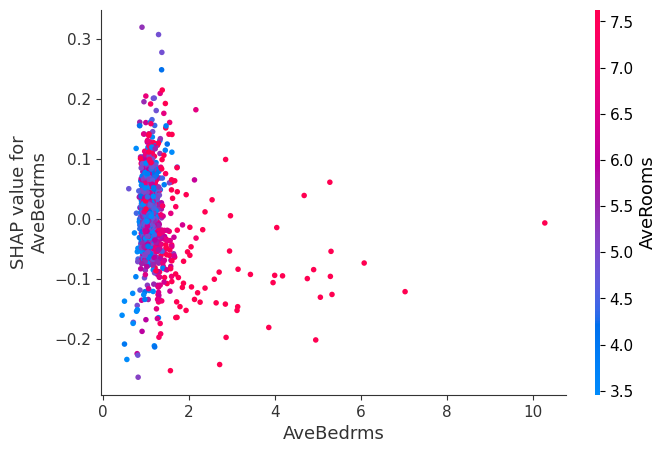

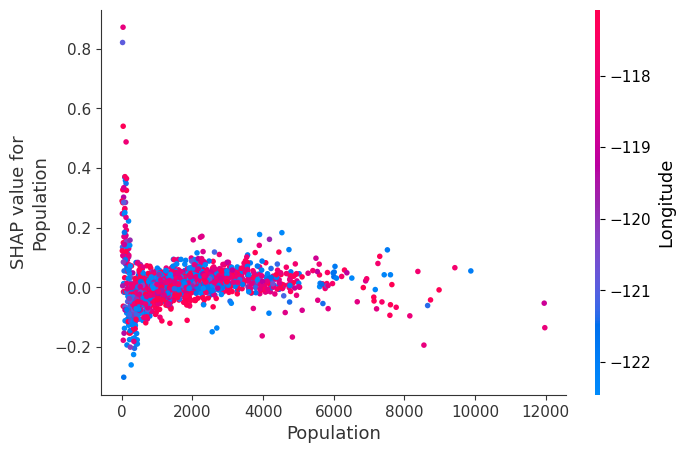

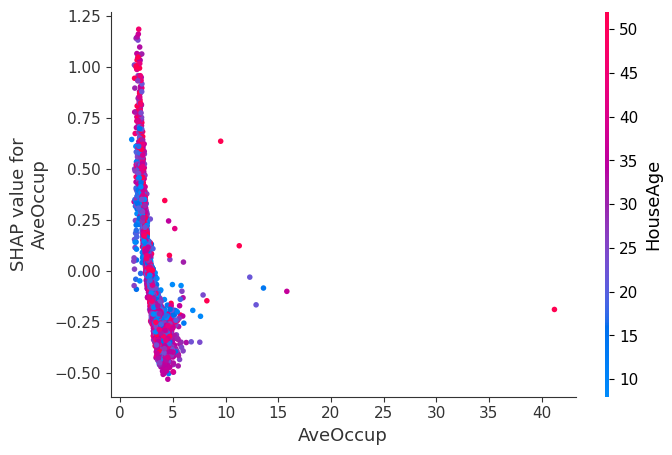

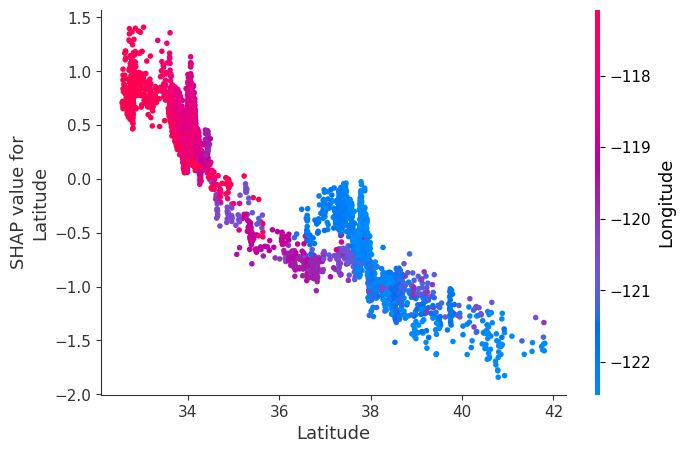

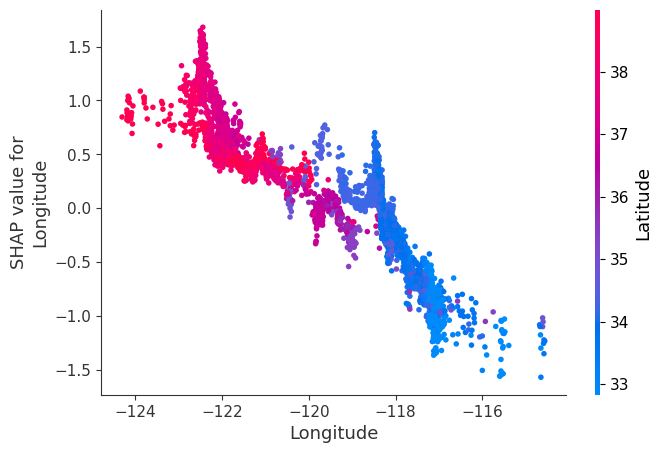

In [21]:
# aquí partimos explicando latitud y longitud

for col in X_test.columns:
    shap.dependence_plot(col, shap_values, X_test, interaction_index="auto")
    plt.show()

### Explicabilidad local

In [22]:
shap.initjs() # Inicializa JavaScript para plots interactivos

In [23]:
# El Force Plot es interactivo y muy bueno para visualizar la "fuerza" de las contribuciones
# hacia arriba o hacia abajo a lo largo de un eje.

# El Waterfall Plot es excelente para ver la secuencia de cómo se construye la predicción 
# a partir del valor base, mostrando claramente la magnitud y dirección de cada paso. Es ideal para informes estáticos.

In [31]:
ii = 9

shap.plots.force(expected_value, shap_values[ii], X_test.iloc[ii])

# f(x) es la prediccion
# veOccup = 2.057 y Longitude = -122.3 son flechas rojas >> contribuyen a aumentar el precio de la vivienda
# hay solo dos features en rojo y 4 en azul
# y además las azules en grupo forman una flecha más larga que la roja, por lo que la predicción es azul (lower)
# y principalmente, se debe a valores de latitud y medinc

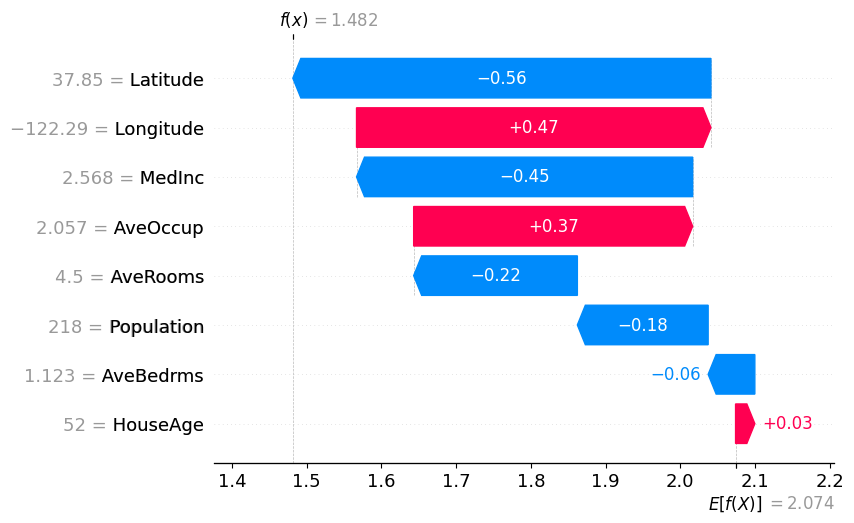

In [34]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[ii],
        base_values=expected_value,
        data=X_test.iloc[ii],
        feature_names=X_test.columns.tolist()
    )
)
plt.show()

# Estos son los SHAP values exactos de cada característica para esta instancia. 
# Por ejemplo, -0.56 para Latitude, +0.47 para Longitude, etc.

# Shapash

In [ ]:
https://shapash-demo.ossbymaif.fr/